In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
left_uploaded = files.upload()
right_uploaded = files.upload()

# read img
left = cv2.imread(list(left_uploaded.keys())[0], 0)
right = cv2.imread(list(right_uploaded.keys())[0], 0)

Saving anita-austvika-li1iEY9JqC8-unsplash.jpg to anita-austvika-li1iEY9JqC8-unsplash.jpg


Saving anita-austvika-li1iEY9JqC8-unsplash.jpg to anita-austvika-li1iEY9JqC8-unsplash (1).jpg


In [3]:
# create orb detector
orb = cv2.ORB_create()

# find keypoints and descriptors
kp1, des1 = orb.detectAndCompute(left, None)
kp2, des2 = orb.detectAndCompute(right, None)

In [4]:
# brute force matcher with hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# match descriptors
matches = bf.match(des1, des2)

# sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

matched_img = cv2.drawMatches(left, kp1, right, kp2, matches[:50], None)

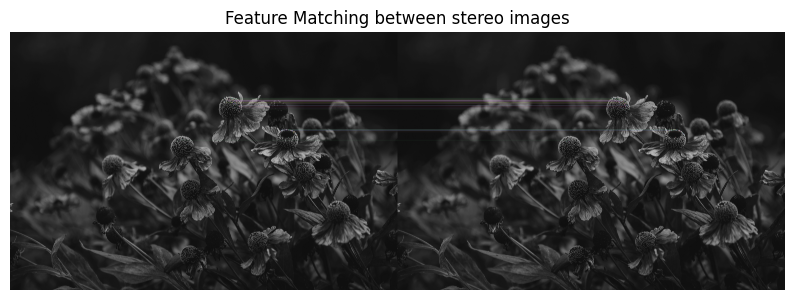

In [5]:
# outputs

plt.figure(figsize=(10, 10))
plt.imshow(matched_img, cmap="gray")
plt.title("Feature Matching between stereo images")
plt.axis("off")
plt.show()